## Tranining CNN from Scratch with MNIST-pytorch

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

### 1. Load and preprocess MNIST dataset

In [19]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081))
])
train_dataset = datasets.MNIST(root='/data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

### 2. Visualize some images

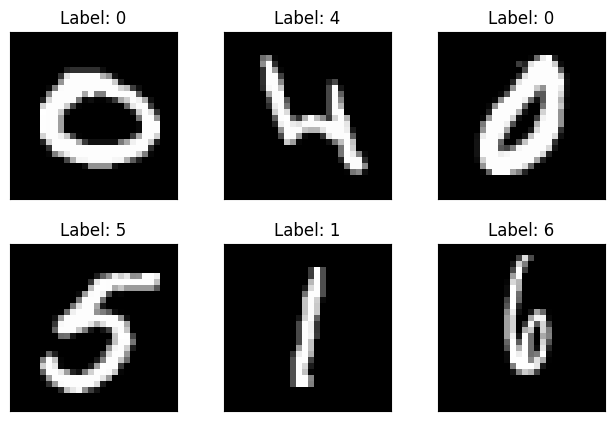

In [20]:
example = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(example)

fig = plt.figure()
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    plt.title("Label: {}".format(example_targets[i]))
    plt.xticks([])
    plt.yticks([])
plt.show()

### 3. Define CNN achitecture

In [21]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x)) # [batch, 32, 26, 26]
        x = F.relu(self.conv2(x)) # [batch, 64, 24, 24]
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

### 4, Instantiate model, define optimizer and loss 

In [22]:
### Model Summary
!pip install torchsummary

Defaulting to user installation because normal site-packages is not writeable


In [23]:
from torchsummary import summary
device = torch.device("Cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             320
            Conv2d-2           [-1, 64, 24, 24]          18,496
         Dropout2d-3           [-1, 64, 12, 12]               0
            Linear-4                  [-1, 128]       1,179,776
           Dropout-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
Total params: 1,199,882
Trainable params: 1,199,882
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.52
Params size (MB): 4.58
Estimated Total Size (MB): 5.10
----------------------------------------------------------------


### 5. Traning loop

In [27]:
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print(f"Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} ] loss: {loss.item():.6}")

### Testing loop

In [28]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0;

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    print(f"\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({accuracy:.2f}%)\n")

### 7. Run traning and testing

In [29]:
for epoch in range(1, 6):
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)

Train Epoch: 1 [0/60000 ] loss: 2.23248
Train Epoch: 1 [6400/60000 ] loss: 0.373399
Train Epoch: 1 [12800/60000 ] loss: 0.124871
Train Epoch: 1 [19200/60000 ] loss: 0.127913
Train Epoch: 1 [25600/60000 ] loss: 0.0963674
Train Epoch: 1 [32000/60000 ] loss: 0.0759993
Train Epoch: 1 [38400/60000 ] loss: 0.140215
Train Epoch: 1 [44800/60000 ] loss: 0.0830137
Train Epoch: 1 [51200/60000 ] loss: 0.227365
Train Epoch: 1 [57600/60000 ] loss: 0.101288

Test set: Average loss: 0.0437, Accuracy: 9861/10000 (98.61%)

Train Epoch: 2 [0/60000 ] loss: 0.0327513
Train Epoch: 2 [6400/60000 ] loss: 0.0928935
Train Epoch: 2 [12800/60000 ] loss: 0.112494
Train Epoch: 2 [19200/60000 ] loss: 0.0453297
Train Epoch: 2 [25600/60000 ] loss: 0.032952
Train Epoch: 2 [32000/60000 ] loss: 0.128505
Train Epoch: 2 [38400/60000 ] loss: 0.0655155
Train Epoch: 2 [44800/60000 ] loss: 0.13875
Train Epoch: 2 [51200/60000 ] loss: 0.146566
Train Epoch: 2 [57600/60000 ] loss: 0.158006

Test set: Average loss: 0.0394, Accuracy

### 8. Save the trained model

In [31]:
model_path =  "mnist_cnn.pth"
torch.save(model.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to mnist_cnn.pth


## 9. Load the save model

In [36]:
#
loaded_model = CNN().to(device)
loaded_model.state_dict(torch.load(model_path))
loaded_model.eval()
print("Model Laoded successfully.")


Model Laoded successfully.


C:\Users\angaj\AppData\Local\Temp\ipykernel_14620\1924818797.py:3: FutureWarning: Positional args are being deprecated, use kwargs instead. Refer to https://pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  loaded_model.state_dict(torch.load(model_path))


### 9. make prediction with laoded model

In [44]:
def Predict(model, device, data_laoder, num_samples=6):
    model.eval()
    data_iter = iter(data_laoder)
    images, labels = next(data_iter)
    images, labels = images.to(device), labels.to(device)
    output = model(images)
    preds = output.argmax(dim=1)


    ## Visualize predictions
    fig = plt.figure()
    for i in range(num_samples):
        plt.subplot(2, 3, i+1)
        plt.tight_layout()
        plt.imshow(images[i][0].cpu(), cmap='gray', interpolation='none')
        plt.title(f"Pred: {preds[i].item()},Lable: {labels[i].item()}")
        plt.xticks([])
        plt.yticks([])

    plt.show()

#### Run Prediction
Predict(loaded_model, device, test_loader)